# 11_数据预处理方法-数据归一化

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇使用代码生成的模拟数据或 scikit-learn 随包附带的小数据集，无需外部数据文件。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


今儿要和大家聊的是数据预处理中的**数据归一化**\~

数据归一化目的是把数据调整到同一尺度上，让各个数据之间比较公平，避免某些量纲特别大的数据“抢占”机器学习模型的权重。

假如，咱们在做一道题，题目中涉及到人的身高（单位：厘米）和体重（单位：公斤）。

通常情况下，身高的数值可能在100到200之间，而体重的数值可能在30到100之间。

如果不处理，模型在计算时可能会觉得“身高”的影响远大于“体重”，因为数值差距太大。

通过归一化，我们可以将不同范围的数据映射到同一个区间（通常是0到1），这样每个特征对模型的贡献就更平衡了。

### 常见的归一化方法 - Min-Max归一化

最常用的一种归一化方法叫做Min-Max归一化，公式：


$$
x_{\text{norm}} = \frac{x - \min(x)}{\max(x) - \min(x)}
$$


其中：

- $x$是原始数据值，
- $\min(x)$是数据中的最小值，
- $\max(x)$是数据中的最大值，
- $x_{\text{norm}}$就是归一化后的数据值，其范围一般在0到1之间。

假设我们有一组数据表示某个班级同学的考试分数，数据为：

原文参考输出或命令说明（无需在 Python 内核执行）：

```text
[40, 60, 80, 90, 100]
```

1. **找最小值和最大值**  
最小值（min）：40  
最大值（max）：100
2. **归一化公式**  
对于每个分数，用公式计算：  
$x_{\text{norm}} = \frac{x - 40}{100 - 40} = \frac{x - 40}{60}$
3. **计算每个分数的归一化值**

   - 对于40分：$\frac{40 - 40}{60} = \frac{0}{60} = 0$
   - 对于60分：$\frac{60 - 40}{60} = \frac{20}{60} \approx 0.33$
   - 对于80分：$\frac{80 - 40}{60} = \frac{40}{60} \approx 0.67$
   - 对于90分：$\frac{90 - 40}{60} = \frac{50}{60} \approx 0.83$
   - 对于100分：$\frac{100 - 40}{60} = \frac{60}{60} = 1$

归一化后，数据就变成了：

原文参考输出或命令说明（无需在 Python 内核执行）：

```text
[0, 0.33, 0.67, 0.83, 1]
```

通过这个简单的例子，相信大家对数据归一化的概念和计算过程有更清晰的理解。

## 公式解析

数据归一化的核心思想是通过线性变换将数据映射到一个固定区间内（通常是[0,1]），以消除不同特征量纲或数值范围上的差异，从而使得各个特征在后续处理（如机器学习算法中）中具有同等重要性。

这里咱们详细介绍 Min-Max 归一化的数学推导和算法原理。

### 1. 问题描述

设有一组原始数据


$$
X = \{x_1, x_2, \dots, x_n\}
$$


其最小值为 $\min(X)$ ，最大值为 $\max(X)$。

目标是构造一个映射函数 $f(x)$，将原始数据 $x$线性映射到区间 $[0, 1]$ 上，使得：

- 当 $x = \min(X)$时，有 $f(x)=0$
- 当 $x = \max(X)$时，有 $f(x)=1$

### 2. 构造线性映射函数

我们假设归一化函数是一个线性函数，其一般形式为：


$$
f(x) = a \cdot x + b
$$


其中，$a$ 和 $b$ 为待求系数。为了满足边界条件，我们需要构造两个方程：

1. 当 $x = \min(X)$时，要求 $f(\min(X))=0$：  
$a \cdot \min(X) + b = 0$
2. 当 $x = \max(X)$时，要求 $f(\max(X))=1$：  
$a \cdot \max(X) + b = 1$

### 3. 求解系数 $a$ 和 $b$

#### 第一步：消去 $b$

从第一个方程得到：$b = -a \cdot \min(X)$

#### 第二步：代入第二个方程

将 $b$ 的表达式代入第二个方程：  
$a \cdot \max(X) - a \cdot \min(X) = 1$  
合并同类项：  
$a \cdot (\max(X) - \min(X)) = 1$

从而解得 $a$：  
$a = \frac{1}{\max(X) - \min(X)}$

#### 第三步：求 $b$

将 $a$ 的值代入 $b = -a \cdot \min(X)$ 得：  
$b = -\frac{\min(X)}{\max(X) - \min(X)}$

---

### 4. 最终归一化公式

将 $a$ 和 $b$ 带回线性函数 $f(x)$：  
$f(x) = \frac{1}{\max(X) - \min(X)} \cdot x - \frac{\min(X)}{\max(X) - \min(X)}$  
化简后可写为：  
$f(x) = \frac{x - \min(X)}{\max(X) - \min(X)}$

这个公式正是常见的 **Min-Max归一化** 公式，它将所有数据 $x$ 映射到区间 [0,1] 内。

---

### 5. 算法推理与验证

#### 算法步骤

1. **计算最小值和最大值：**  
对数据集 $X$ 计算 $\min(X)$ 和 $\max(X)$。
2. **线性变换：**  
对于每个数据 $x$，计算归一化值：  
$x_{\text{norm}} = \frac{x - \min(X)}{\max(X) - \min(X)}$
3. **验证边界条件：**

   - 当 $x = \min(X)$ 时：  
   $x_{\text{norm}} = \frac{\min(X) - \min(X)}{\max(X) - \min(X)} = 0$
   - 当 $x = \max(X)$ 时：  
   $x_{\text{norm}} = \frac{\max(X) - \min(X)}{\max(X) - \min(X)} = 1$

#### 数学推理的意义

- **线性映射保证了数据的相对间隔保持不变：**由于变换是线性的，原始数据中的相对距离得以保留，便于后续模型学习到数据本身的分布和差异。
- **数据范围统一化：**将数据映射到 [0, 1] 区间后，各特征不会因为数值范围不同而对模型产生不均衡的影响，特别是在距离度量、梯度下降等算法中非常重要。

## 完整案例

代码中使用了考试分数作为示例数据，采用 Min-Max 数据归一化方法\~

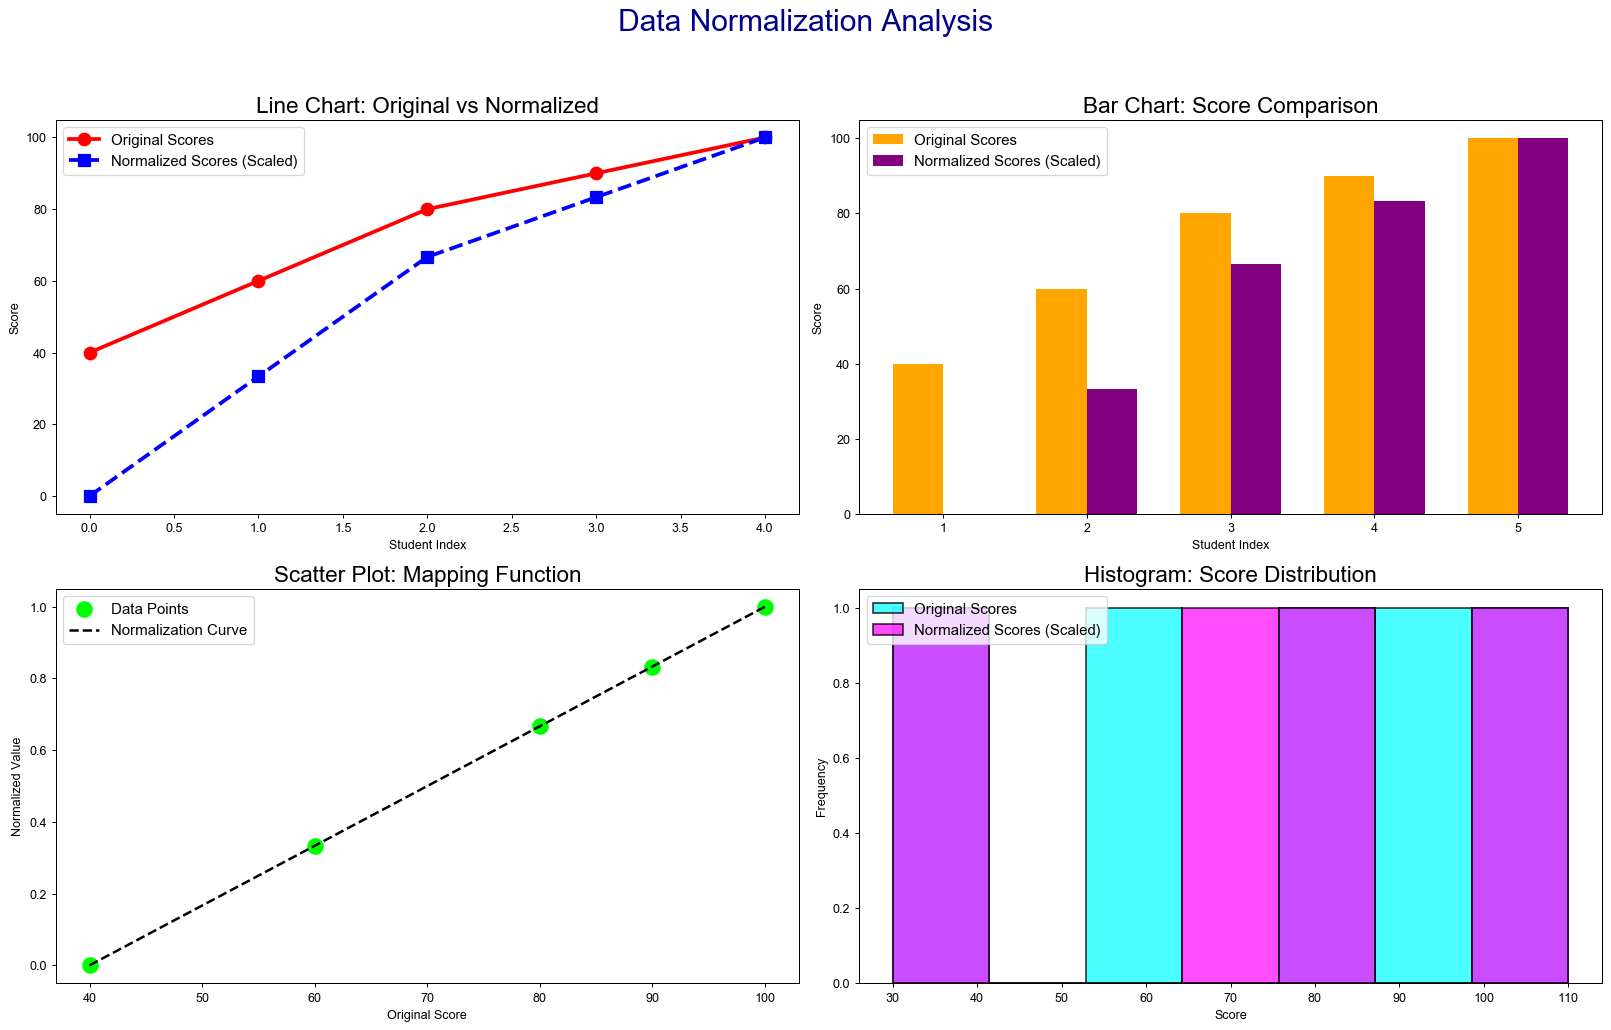

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# 数据准备：考试分数
original_scores = np.array([40, 60, 80, 90, 100])

# 数据归一化 (Min-Max Normalization)
# 计算数据最小值和最大值
min_val = np.min(original_scores)
max_val = np.max(original_scores)
# 应用归一化公式：x_norm = (x - min) / (max - min)
normalized_scores = (original_scores - min_val) / (max_val - min_val)
# 为了直观对比，将归一化结果乘以100（归一化后的数据放大，以便与原始分数做对比展示）
normalized_scaled = normalized_scores * 100

# 创建一个包含4个子图的画布 (2行2列)
fig, axs = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle("Data Normalization Analysis", fontsize=24, color='darkblue')

# 子图1：折线图 - 展示原始分数与归一化分数趋势
axs[0, 0].plot(original_scores, color='red', marker='o', linestyle='-', linewidth=3, markersize=10, label='Original Scores')
axs[0, 0].plot(normalized_scaled, color='blue', marker='s', linestyle='--', linewidth=3, markersize=10, label='Normalized Scores (Scaled)')
axs[0, 0].set_title("Line Chart: Original vs Normalized", fontsize=18)
axs[0, 0].set_xlabel("Student Index")
axs[0, 0].set_ylabel("Score")
axs[0, 0].legend(fontsize=12)

# 子图2：柱状图 - 对比原始分数与归一化分数
index = np.arange(len(original_scores))
bar_width = 0.35
axs[0, 1].bar(index, original_scores, bar_width, color='orange', label='Original Scores')
axs[0, 1].bar(index + bar_width, normalized_scaled, bar_width, color='purple', label='Normalized Scores (Scaled)')
axs[0, 1].set_title("Bar Chart: Score Comparison", fontsize=18)
axs[0, 1].set_xlabel("Student Index")
axs[0, 1].set_ylabel("Score")
axs[0, 1].set_xticks(index + bar_width / 2)
axs[0, 1].set_xticklabels([str(i+1) for i in range(len(original_scores))])
axs[0, 1].legend(fontsize=12)

# 子图3：散点图 - 展示原始分数与归一化值之间的映射关系
axs[1, 0].scatter(original_scores, normalized_scores, color='lime', s=150, label='Data Points')
# 绘制归一化映射曲线，说明归一化函数的线性映射关系
x_line = np.linspace(min_val, max_val, 100)
y_line = (x_line - min_val) / (max_val - min_val)
axs[1, 0].plot(x_line, y_line, color='black', linestyle='--', linewidth=2, label='Normalization Curve')
axs[1, 0].set_title("Scatter Plot: Mapping Function", fontsize=18)
axs[1, 0].set_xlabel("Original Score")
axs[1, 0].set_ylabel("Normalized Value")
axs[1, 0].legend(fontsize=12)

# 子图4：直方图 - 展示原始分数与归一化分数的分布情况
bins = np.linspace(30, 110, 8)  # 自定义bins范围，使得两组数据的分布直方图便于对比
axs[1, 1].hist(original_scores, bins=bins, color='cyan', alpha=0.7, label='Original Scores', edgecolor='black', linewidth=1.5)
axs[1, 1].hist(normalized_scaled, bins=bins, color='magenta', alpha=0.7, label='Normalized Scores (Scaled)', edgecolor='black', linewidth=1.5)
axs[1, 1].set_title("Histogram: Score Distribution", fontsize=18)
axs[1, 1].set_xlabel("Score")
axs[1, 1].set_ylabel("Frequency")
axs[1, 1].legend(fontsize=12)

# 调整子图间距，避免重叠
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

![原文参考图，当前结果见代码输出](attachments/img_011.png)

1. **图1（折线图）：**展示了原始考试分数与归一化后（并乘以100）的分数随学生序号变化的趋势。

   - **红色实线与圆形标记**：表示原始分数。
   - **蓝色虚线与方形标记**：表示归一化后（经过放大处理）的分数。  
   大家可以清晰看到两组数据的走势。虽然归一化后的数据经过线性变换，但其相对的变化趋势与原始数据是一致的，这证明归一化过程保留了原始数据的分布特性，同时消除了不同量纲之间的影响。
2. **图2（柱状图）：**通过柱状图的方式对比展示了每个学生的原始分数和归一化后分数。

   - **橙色柱状图**：表示原始分数。
   - **紫色柱状图**：表示归一化后（放大后）的分数。  
   柱状图能够直观对比不同学生之间的分数差异，同时可以观察到归一化数据的分布与原始数据的对应关系。通过并排显示两组数据，不仅可以看出数据的绝对值差异，还能体会到归一化操作对数据尺度调整的作用。
3. **图3（散点图）：**展示了原始分数与归一化值之间的映射关系。

   - **绿色散点**：每个点对应一个学生的原始分数与其归一化值。
   - **黑色虚线**：表示归一化的映射曲线，即根据公式 $y = \frac{x - \min(X)}{\max(X) - \min(X)}$得到的线性关系。  
   散点图结合映射曲线，可以直观验证归一化公式的正确性，并且展示了数据在转换前后的数值对应关系。对于机器学习算法来说，这种映射关系至关重要，因为它保证了数据的线性可解释性和数值稳定性。
4. **图4（直方图）：**直方图用来展示原始分数和归一化后分数的分布情况。

   - 直方图中的**青色**部分代表原始分数的分布，
   - **洋红色**部分代表归一化后（放大后）的分数分布。  
   通过直方图，我们可以观察到数据分布的集中趋势和离散程度。由于数据量较少，直方图的分布较为简单，但依然可以看出归一化处理使得数据处于同一比较尺度上，便于进一步的统计分析。

总的来说，数据归一化作为一种简单而有效的预处理技术，不仅能够提升模型的训练效率和稳定性，还为数据可视化和深入分析提供了便利条件。